### Strings

In [1]:
import numpy as np
import pandas as pd

In [3]:
# What are vectorized operations
a=np.array([1,2,3,4])
a*4

array([ 4,  8, 12, 16])

In [ ]:
# problem in vectorized opertions in vanilla python
s = pd.Series(['cat','mat',None,'rat'])
[i.startswith('c') for i in s]


In [ ]:
# How pandas solves this issue?

s = pd.Series(['cat','mat',None,'rat'])

# string accessor
s.str.startswith('c')

# fast and optimized

0    cat
dtype: str

In [11]:
# import titanic
df = pd.read_csv('csv_files/titanic.csv')
df['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: str

In [ ]:
# Common Functions
# lower/upper/capitalize/title
df['Name'].str.upper()
df['Name'].str.capitalize()
df['Name'].str.title()

# len
df['Name'][df['Name'].str.len() == 82].values[0]

# strip
"                   nitish                              ".strip()
df['Name'].str.strip()

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: str

In [23]:
# split -> get
df['lastname']=df['Name'].str.split(',').str.get(0)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen


In [33]:
df[['title','firstname']]=df['Name'].str.split(',').str.get(1).str.strip().str.split(' ',n=1,expand=True)
df.head()

df['title'].value_counts()

title
Mr.          517
Miss.        182
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Major.         2
Mlle.          2
Col.           2
Don.           1
Mme.           1
Ms.            1
Lady.          1
Sir.           1
Capt.          1
the            1
Jonkheer.      1
Name: count, dtype: int64

In [36]:
# replace
df['title']=df['title'].str.replace('Ms.','Miss.')
df['title']=df['title'].str.replace('Mlle.','Miss.')
df['title'].value_counts()

title
Mr.          517
Miss.        185
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Major.         2
Col.           2
Don.           1
Mme.           1
Lady.          1
Sir.           1
Capt.          1
the            1
Jonkheer.      1
Name: count, dtype: int64

In [41]:
# filtering
# startswith/endswith
df[df['firstname'].str.endswith('A')]

# isdigit/isalpha...
df[df['firstname'].str.isdigit()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,title,firstname


In [43]:
# applying regular experesion

# contains
# search john -> both case
df[df['firstname'].str.contains('john',case=False)]

# find lastnames with start and end char vowel
df[df['lastname'].str.contains('^[^aeiouAEIOU].+[^aeiouAEIOU]$')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,title,firstname
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr.,Owen Harris
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs.,John Bradley (Florence Briggs Thayer)
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss.,Laina
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Moran,Mr.,James
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,McCarthy,Mr.,Timothy J
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S,Sutehall,Mr.,Henry Jr
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Graham,Miss.,Margaret Edith
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Johnston,Miss.,"Catherine Helen ""Carrie"""
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Behr,Mr.,Karl Howell


In [44]:
# slicing
df['Name'].str[::-1]

0                                sirraH newO .rM ,dnuarB
1      )reyahT sggirB ecnerolF( yeldarB nhoJ .srM ,sg...
2                                 aniaL .ssiM ,nenikkieH
3           )leeP yaM yliL( htaeH seuqcaJ .srM ,ellertuF
4                               yrneH mailliW .rM ,nellA
                             ...                        
886                                sazouJ .veR ,alivtnoM
887                         htidE teragraM .ssiM ,maharG
888             "eirraC" neleH enirehtaC .ssiM ,notsnhoJ
889                                llewoH lraK .rM ,rheB
890                                  kcirtaP .rM ,yelooD
Name: Name, Length: 891, dtype: str

### Date and Time

In [45]:
import numpy as np
import pandas as pd

#### Timestamp Object

Time stamps reference particular moments in time (e.g., Oct 24th, 2022 at 7:00pm)

#### Creating Timestamp objects

In [50]:
# creating a timestamp
type(pd.Timestamp('2026/6/25'))

pandas.Timestamp

In [56]:
# variations
pd.Timestamp('2026-6-25')
pd.Timestamp('2026, 6, 25')

Timestamp('2026-06-25 00:00:00')

In [57]:
# only year
pd.Timestamp('2026')

Timestamp('2026-01-01 00:00:00')

In [58]:
# using text
pd.Timestamp('5th January 2026')

Timestamp('2026-01-05 00:00:00')

In [60]:
# providing time also
pd.Timestamp('5th January 2023 9:21AM')
#pd.Timestamp('2023,1,5,9,21')

Timestamp('2023-01-05 09:21:00')

In [ ]:
# AM and PM

In [64]:
# using datetime.datetime object
import datetime as dt

x = pd.Timestamp(dt.datetime(2026,1,5,9,21,56))
x

Timestamp('2026-01-05 09:21:56')

In [70]:
# fetching attributes
x.year
x.month
x.day
x.hour
x.minute
x.second

56

In [ ]:
# why separate objects to handle data and time when python already has datetime functionality?

syntax wise datetime is very convenient

But the performance takes a hit while working with huge data. List vs Numpy Array

The weaknesses of Python's datetime format inspired the NumPy team to add a set of native time series data type to NumPy.

The datetime64 dtype encodes dates as 64-bit integers, and thus allows arrays of dates to be represented very compactly.

In [72]:
import numpy as np
date = np.array('2026-07-04', dtype=np.datetime64)
date

array('2026-07-04', dtype='datetime64[D]')

In [73]:
date + np.arange(12)

array(['2026-07-04', '2026-07-05', '2026-07-06', '2026-07-07',
       '2026-07-08', '2026-07-09', '2026-07-10', '2026-07-11',
       '2026-07-12', '2026-07-13', '2026-07-14', '2026-07-15'],
      dtype='datetime64[D]')

Because of the uniform type in NumPy datetime64 arrays, this type of operation can be accomplished much more quickly than if we were working directly with Python's datetime objects, especially as arrays get large

Pandas Timestamp object combines the ease-of-use of python datetime with the efficient storage and vectorized interface of numpy.datetime64

From a group of these Timestamp objects, Pandas can construct a DatetimeIndex that can be used to index data in a Series or DataFrame

#### DatetimeIndex Object

A collection of pandas timestamp

In [78]:
# from strings
type(pd.DatetimeIndex(['2026/1/1','2025/1/1','2024/1/1']))

pandas.DatetimeIndex

In [79]:
# using python datetime object
pd.DatetimeIndex([dt.datetime(2026,1,1),dt.datetime(2025,1,1),dt.datetime(2024,1,1)])

DatetimeIndex(['2026-01-01', '2025-01-01', '2024-01-01'], dtype='datetime64[us]', freq=None)

In [82]:
# using pd.timestamps
dt_index = pd.DatetimeIndex([pd.Timestamp(2026,1,1),pd.Timestamp(2025,1,1),pd.Timestamp(2024,1,1)])
dt_index

DatetimeIndex(['2026-01-01', '2025-01-01', '2024-01-01'], dtype='datetime64[us]', freq=None)

In [83]:
# using datatimeindex as series index
pd.Series([1,2,3],index=dt_index)

2026-01-01    1
2025-01-01    2
2024-01-01    3
dtype: int64

#### date_range function

In [84]:
# generate daily dates in a given range
pd.date_range(start='2026/1/5',end='2026/2/28',freq='3D')

DatetimeIndex(['2026-01-05', '2026-01-08', '2026-01-11', '2026-01-14',
               '2026-01-17', '2026-01-20', '2026-01-23', '2026-01-26',
               '2026-01-29', '2026-02-01', '2026-02-04', '2026-02-07',
               '2026-02-10', '2026-02-13', '2026-02-16', '2026-02-19',
               '2026-02-22', '2026-02-25', '2026-02-28'],
              dtype='datetime64[us]', freq='3D')

In [88]:
# alternate days in a given range
pd.date_range(start='2026/1/5',end='2026/2/28',freq='3D')

DatetimeIndex(['2026-01-05', '2026-01-08', '2026-01-11', '2026-01-14',
               '2026-01-17', '2026-01-20', '2026-01-23', '2026-01-26',
               '2026-01-29', '2026-02-01', '2026-02-04', '2026-02-07',
               '2026-02-10', '2026-02-13', '2026-02-16', '2026-02-19',
               '2026-02-22', '2026-02-25', '2026-02-28'],
              dtype='datetime64[us]', freq='3D')

In [89]:
# B -> business days
pd.date_range(start='2026/1/5',end='2026/2/28',freq='B')

DatetimeIndex(['2026-01-05', '2026-01-06', '2026-01-07', '2026-01-08',
               '2026-01-09', '2026-01-12', '2026-01-13', '2026-01-14',
               '2026-01-15', '2026-01-16', '2026-01-19', '2026-01-20',
               '2026-01-21', '2026-01-22', '2026-01-23', '2026-01-26',
               '2026-01-27', '2026-01-28', '2026-01-29', '2026-01-30',
               '2026-02-02', '2026-02-03', '2026-02-04', '2026-02-05',
               '2026-02-06', '2026-02-09', '2026-02-10', '2026-02-11',
               '2026-02-12', '2026-02-13', '2026-02-16', '2026-02-17',
               '2026-02-18', '2026-02-19', '2026-02-20', '2026-02-23',
               '2026-02-24', '2026-02-25', '2026-02-26', '2026-02-27'],
              dtype='datetime64[us]', freq='B')

In [93]:
# W -> one week per day
pd.date_range(start='2026/1/5',end='2026/2/28',freq='W-THU')

DatetimeIndex(['2026-01-08', '2026-01-15', '2026-01-22', '2026-01-29',
               '2026-02-05', '2026-02-12', '2026-02-19', '2026-02-26'],
              dtype='datetime64[us]', freq='W-THU')

In [ ]:
# h -> Hourly data(factor)
pd.date_range(start='2026/1/5',end='2026/2/28',freq='6h')

DatetimeIndex(['2026-01-05 00:00:00', '2026-01-05 06:00:00',
               '2026-01-05 12:00:00', '2026-01-05 18:00:00',
               '2026-01-06 00:00:00', '2026-01-06 06:00:00',
               '2026-01-06 12:00:00', '2026-01-06 18:00:00',
               '2026-01-07 00:00:00', '2026-01-07 06:00:00',
               ...
               '2026-02-25 18:00:00', '2026-02-26 00:00:00',
               '2026-02-26 06:00:00', '2026-02-26 12:00:00',
               '2026-02-26 18:00:00', '2026-02-27 00:00:00',
               '2026-02-27 06:00:00', '2026-02-27 12:00:00',
               '2026-02-27 18:00:00', '2026-02-28 00:00:00'],
              dtype='datetime64[us]', length=217, freq='6h')

In [ ]:
# ME -> Month end
pd.date_range(start='2026/1/5',end='2026/2/28',freq='ME')

DatetimeIndex(['2026-01-31', '2026-02-28'], dtype='datetime64[us]', freq='ME')

In [98]:
# MS -> Month start
pd.date_range(start='2026/1/5',end='2026/2/28',freq='MS')

DatetimeIndex(['2026-02-01'], dtype='datetime64[us]', freq='MS')

In [101]:
# YE -> Year end
pd.date_range(start='2026/1/5',end='2026/2/28',freq='YE')

DatetimeIndex([], dtype='datetime64[us]', freq='YE-DEC')

In [103]:
# using periods(number of results)
pd.date_range(start='2026/1/5',periods=25,freq='ME')

DatetimeIndex(['2026-01-31', '2026-02-28', '2026-03-31', '2026-04-30',
               '2026-05-31', '2026-06-30', '2026-07-31', '2026-08-31',
               '2026-09-30', '2026-10-31', '2026-11-30', '2026-12-31',
               '2027-01-31', '2027-02-28', '2027-03-31', '2027-04-30',
               '2027-05-31', '2027-06-30', '2027-07-31', '2027-08-31',
               '2027-09-30', '2027-10-31', '2027-11-30', '2027-12-31',
               '2028-01-31'],
              dtype='datetime64[us]', freq='ME')

#### to_datetime function

converts an existing objects to pandas timestamp/datetimeindex object

In [109]:
# simple series example

s = pd.Series(['2026/1/1','2025/1/1','2024/1/1'])
pd.to_datetime(s).dt.day_name()

0     Thursday
1    Wednesday
2       Monday
dtype: str

In [115]:
# with errors
s = pd.Series(['2026/1/1','2025/1/1','2024/130/1'])
pd.to_datetime(s,errors='coerce').dt.month_name()

0    January
1    January
2        NaN
dtype: str

In [106]:
df = pd.read_csv('csv_files/expense_data.csv')
df.shape

(277, 11)

In [110]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [118]:
df['Date'] = pd.to_datetime(df['Date'])

In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[us]
 1   Account         277 non-null    str           
 2   Category        277 non-null    str           
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    str           
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    str           
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    str           
 10  Account.1       277 non-null    float64       
dtypes: datetime64[us](1), float64(5), str(5)
memory usage: 23.9 KB


dt accessor

Accessor object for datetimelike properties of the Series values.

In [ ]:
df['Date'].dt.is_quarter_start

0      False
1      False
2      False
3      False
4      False
       ...  
272    False
273    False
274    False
275    False
276    False
Name: Date, Length: 277, dtype: bool

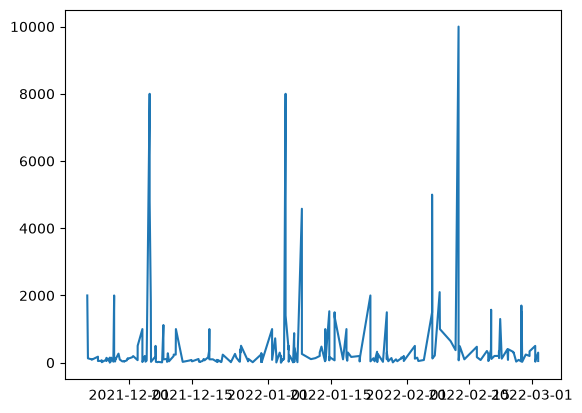

In [120]:
# plot graph
import matplotlib.pyplot as plt
plt.plot(df['Date'],df['INR'])

In [123]:
# day name wise bar chart/month wise bar chart
df['day_name'] = df['Date'].dt.day_name()

<Axes: xlabel='day_name'>

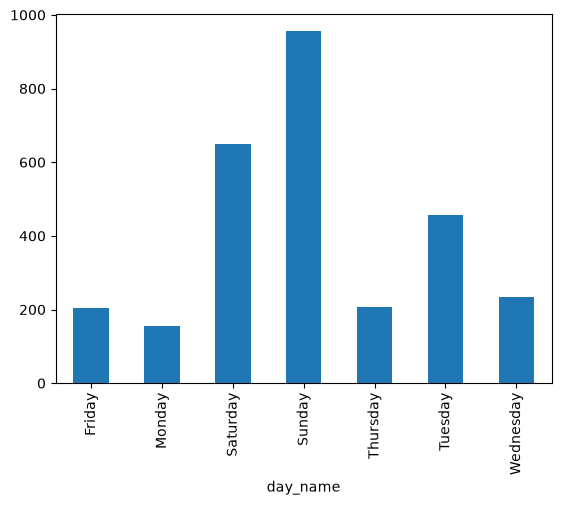

In [124]:
df.groupby('day_name')['INR'].mean().plot(kind='bar')

In [125]:
df['month_name'] = df['Date'].dt.month_name()
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month_name,day_name
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March,Wednesday
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March,Wednesday
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March,Tuesday
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March,Tuesday
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March,Tuesday


<Axes: xlabel='month_name'>

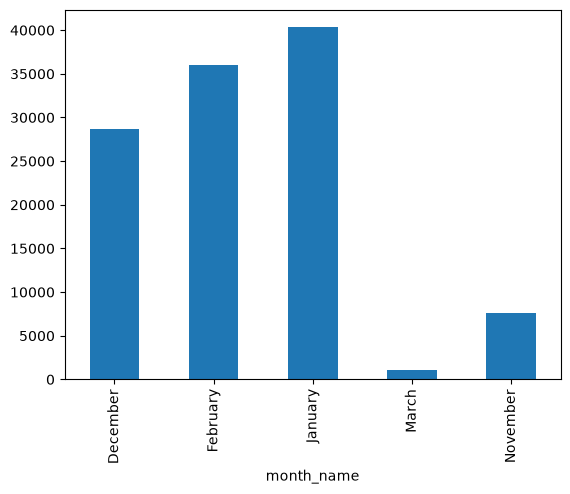

In [129]:
df.groupby('month_name')['INR'].sum().plot(kind='bar')

In [127]:
df[df['Date'].dt.is_month_end]

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month_name,day_name
7,2022-02-28 11:56:00,CUB - online payment,Food,NaN,Pizza,339.15,Expense,NaN,339.15,INR,339.15,February,Monday
8,2022-02-28 11:45:00,CUB - online payment,Other,NaN,From kumara,200.00,Income,NaN,200.00,INR,200.00,February,Monday
61,2022-01-31 08:44:00,CUB - online payment,Transportation,NaN,Vnr to apk,50.00,Expense,NaN,50.00,INR,50.00,January,Monday
62,2022-01-31 08:27:00,CUB - online payment,Other,NaN,To vicky,200.00,Expense,NaN,200.00,INR,200.00,January,Monday
63,2022-01-31 08:26:00,CUB - online payment,Transportation,NaN,To ksr station,153.00,Expense,NaN,153.00,INR,153.00,January,Monday
242,2021-11-30 14:24:00,CUB - online payment,Gift,NaN,Bharath birthday,115.00,Expense,NaN,115.00,INR,115.00,November,Tuesday
243,2021-11-30 14:17:00,CUB - online payment,Food,NaN,Lunch with company,128.00,Expense,NaN,128.00,INR,128.00,November,Tuesday
244,2021-11-30 10:11:00,CUB - online payment,Food,NaN,Breakfast,70.00,Expense,NaN,70.00,INR,70.00,November,Tuesday
